# Problema - Organización y búsqueda de productos en una tienda

**Tema:** Comparación entre Árbol Binario de Búsqueda (BST) y Árbol AVL.

El programa recibe una cantidad `n` de códigos de productos, los guarda inicialmente en una lista y utiliza exactamente el mismo orden de inserción para construir un BST y un AVL.

Se implementan manualmente:
- Inserción BST.
- Inserción AVL y balanceo mediante rotaciones.
- Recorridos Preorden, Inorden y Postorden.
- Visualización gráfica de ambos árboles.


In [ ]:
# @title Ingrese datos
nombre_estudiante = "Jorge Santiago Silva Walteros"  # @param {"type":"string"}
carnet = 1000114041  # @param {"type":"integer"}


codigos = [30, 20, 10, 25, 28, 27, 5, 50]


n = len(codigos)

print("Cantidad de productos:", n)
print("Códigos:", codigos)


Cantidad de productos: 8
Códigos: [30, 20, 10, 25, 28, 27, 5, 50]


## 1) Descripción del problema **[1 pts]**

Una empresa necesita organizar los códigos numéricos de los productos almacenados en una bodega. Los códigos llegan en un orden determinado y se desea comparar el comportamiento de un Árbol Binario de Búsqueda (BST) con un Árbol AVL.

El BST conserva exactamente el orden de inserción y no realiza balanceo. El AVL utiliza el mismo orden de inserción, pero después de cada inserción calcula el factor de balance y realiza las rotaciones necesarias cuando un nodo queda desbalanceado.

El sistema también permite realizar los recorridos Preorden, Inorden y Postorden y visualizar gráficamente los dos árboles.


## 2) Requerimientos **[2 pts]**

### Requerimientos funcionales
1. Permitir registrar la cantidad de productos.
2. Permitir ingresar los códigos numéricos.
3. Almacenar los códigos inicialmente en una lista.
4. Construir un BST mediante inserción manual y sin balanceo.
5. Construir un AVL utilizando exactamente los mismos códigos y el mismo orden.
6. Calcular el factor de balance del AVL.
7. Aplicar rotaciones simples y dobles cuando sean necesarias.
8. Realizar los recorridos Preorden, Inorden y Postorden de ambos árboles.
9. Mostrar gráficamente el BST y el AVL.
10. Permitir verificar los resultados de los recorridos mediante pruebas.

### Requerimientos no funcionales
1. El código debe ser claro y modular.
2. La inserción y el balanceo deben estar implementados manualmente.
3. Los recorridos deben utilizar recursividad.
4. La visualización debe permitir distinguir nodos y conexiones.
5. El programa debe ser ejecutable en Jupyter Notebook.


## 3) Historias de usuario **[2 pts]**

### Historia 1
Como encargado de la bodega, quiero ingresar los códigos de los productos, para organizarlos en estructuras de árboles.

**Criterios de aceptación:**
- Se solicita la cantidad de códigos.
- Los códigos quedan almacenados en una lista.
- Se conserva el orden en que fueron ingresados.

### Historia 2
Como usuario del sistema, quiero construir un BST y un AVL con los mismos datos, para comparar sus estructuras.

**Criterios de aceptación:**
- Ambos árboles utilizan los mismos códigos.
- El BST no se balancea.
- El AVL realiza las rotaciones necesarias.

### Historia 3
Como usuario, quiero recorrer los árboles en preorden, inorden y postorden, para consultar sus elementos en diferentes órdenes.

**Criterios de aceptación:**
- Los tres recorridos funcionan de forma recursiva.
- Se muestran los resultados tanto del BST como del AVL.

### Historia 4
Como usuario, quiero visualizar los árboles gráficamente, para observar sus nodos, hijos y conexiones.

**Criterios de aceptación:**
- Se muestra la raíz.
- Se muestran las conexiones entre padres e hijos.
- Se pueden comparar visualmente ambos árboles.


## 4) Diagramas de flujo **[5 pts]**

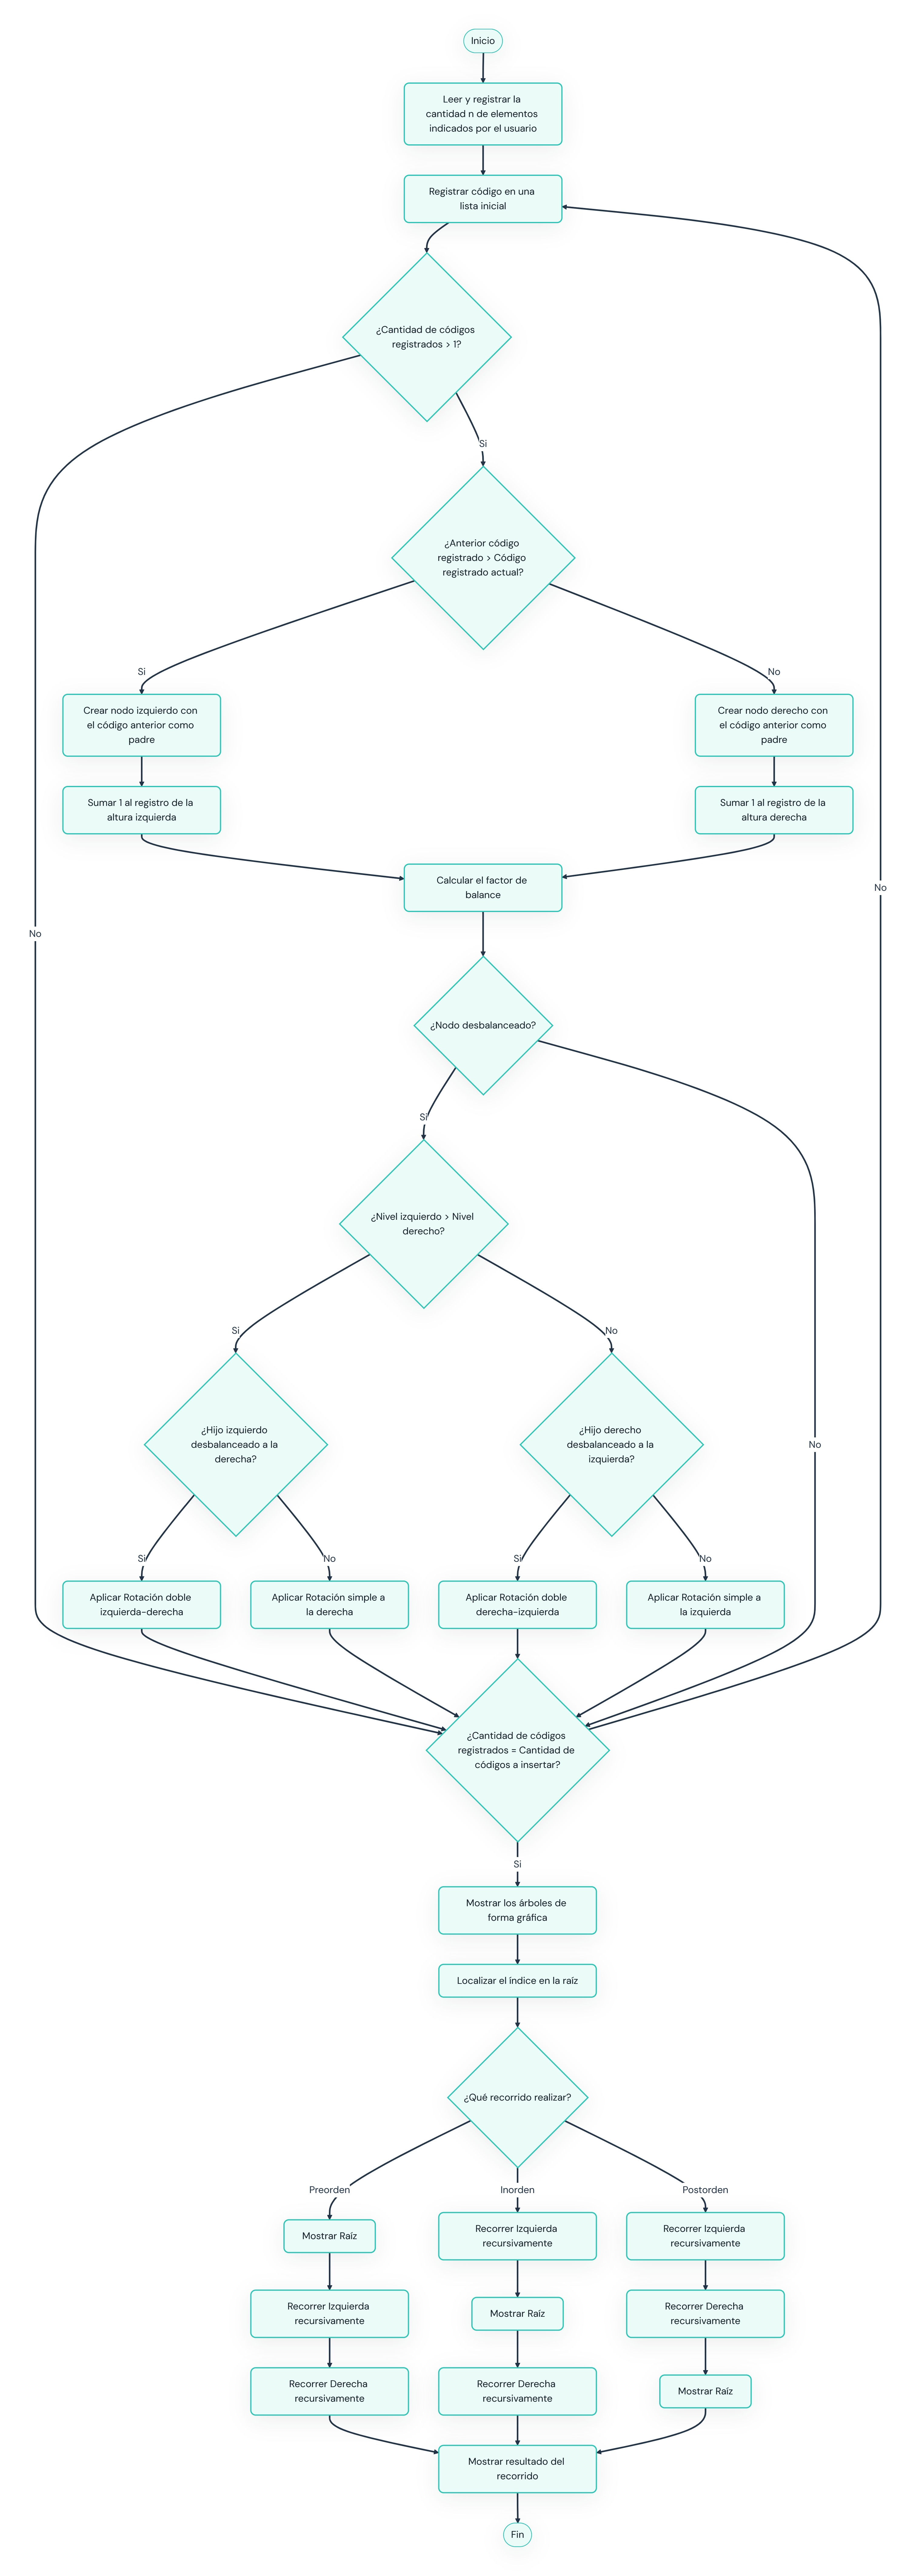


## 5) Análisis de complejidad **[15 pts]**

### BST

Para una inserción en un BST:
- Mejor caso: O(log n), cuando el árbol está razonablemente equilibrado.
- Peor caso: O(n), cuando el árbol queda muy inclinado.

Construir el árbol completo cuesta:
- Mejor caso: O(n log n).
- Peor caso: O(n²).

### AVL

El AVL mantiene una altura O(log n), por lo que:
- Una inserción cuesta O(log n).
- Construir el árbol con n elementos cuesta O(n log n).

Los recorridos Preorden, Inorden y Postorden visitan cada nodo exactamente una vez:
- Tiempo: O(n).
- Espacio adicional por recursividad: O(h), donde h es la altura del árbol.

### Función T[n]

Para los recorridos:

T(n) = T(n_izquierda) + T(n_derecha) + c

Como cada nodo se procesa una vez:

T(n) = O(n)

Para la inserción de un BST, el costo depende de la altura h:

T(n) = O(h)

En un BST equilibrado h ≈ log(n) y en el peor caso h = n.


In [9]:
# Librerías para la visualización
import matplotlib.pyplot as plt
from collections import deque


## 6) Código funcional **[15 pts]**

El siguiente código implementa manualmente el BST, el AVL, las rotaciones, los tres recorridos y la visualización gráfica.


In [ ]:


class Nodo:
    def __init__(self, valor):
        self.valor = valor
        self.izquierda = None
        self.derecha = None
        self.altura = 1




class BST:
    def __init__(self):
        self.raiz = None

    def insertar(self, valor):
        self.raiz = self._insertar(self.raiz, valor)

    def _insertar(self, nodo, valor):
        if nodo is None:
            return Nodo(valor)

        if valor < nodo.valor:
            nodo.izquierda = self._insertar(nodo.izquierda, valor)
        elif valor > nodo.valor:
            nodo.derecha = self._insertar(nodo.derecha, valor)

        return nodo




class AVL:
    def __init__(self):
        self.raiz = None

    def altura(self, nodo):
        if nodo is None:
            return 0
        return nodo.altura

    def actualizar_altura(self, nodo):
        nodo.altura = 1 + max(
            self.altura(nodo.izquierda),
            self.altura(nodo.derecha)
        )

    def factor_balance(self, nodo):
        if nodo is None:
            return 0

        return self.altura(nodo.izquierda) - self.altura(nodo.derecha)

    # Rotación simple a la derecha
    def rotacion_derecha(self, y):
        x = y.izquierda
        subarbol = x.derecha

        x.derecha = y
        y.izquierda = subarbol

        self.actualizar_altura(y)
        self.actualizar_altura(x)

        return x

    # Rotación simple a la izquierda
    def rotacion_izquierda(self, x):
        y = x.derecha
        subarbol = y.izquierda

        y.izquierda = x
        x.derecha = subarbol

        self.actualizar_altura(x)
        self.actualizar_altura(y)

        return y

    def insertar(self, valor):
        self.raiz = self._insertar(self.raiz, valor)

    def _insertar(self, nodo, valor):
        # Inserción normal de BST
        if nodo is None:
            return Nodo(valor)

        if valor < nodo.valor:
            nodo.izquierda = self._insertar(nodo.izquierda, valor)
        elif valor > nodo.valor:
            nodo.derecha = self._insertar(nodo.derecha, valor)
        else:
            return nodo

        # Actualizar altura
        self.actualizar_altura(nodo)

        # Calcular factor de balance
        balance = self.factor_balance(nodo)

        # Caso Izquierda-Izquierda
        if balance > 1 and valor < nodo.izquierda.valor:
            return self.rotacion_derecha(nodo)

        # Caso Derecha-Derecha
        if balance < -1 and valor > nodo.derecha.valor:
            return self.rotacion_izquierda(nodo)

        # Caso Izquierda-Derecha
        if balance > 1 and valor > nodo.izquierda.valor:
            nodo.izquierda = self.rotacion_izquierda(nodo.izquierda)
            return self.rotacion_derecha(nodo)

        # Caso Derecha-Izquierda
        if balance < -1 and valor < nodo.derecha.valor:
            nodo.derecha = self.rotacion_derecha(nodo.derecha)
            return self.rotacion_izquierda(nodo)

        return nodo




def preorden(nodo, resultado=None):
    if resultado is None:
        resultado = []

    if nodo is not None:
        resultado.append(nodo.valor)
        preorden(nodo.izquierda, resultado)
        preorden(nodo.derecha, resultado)

    return resultado


def inorden(nodo, resultado=None):
    if resultado is None:
        resultado = []

    if nodo is not None:
        inorden(nodo.izquierda, resultado)
        resultado.append(nodo.valor)
        inorden(nodo.derecha, resultado)

    return resultado


def postorden(nodo, resultado=None):
    if resultado is None:
        resultado = []

    if nodo is not None:
        postorden(nodo.izquierda, resultado)
        postorden(nodo.derecha, resultado)
        resultado.append(nodo.valor)

    return resultado




bst = BST()
avl = AVL()

for codigo in codigos:
    bst.insertar(codigo)
    avl.insertar(codigo)

print("Árboles construidos correctamente.")


Árboles construidos correctamente.


In [25]:


class BST:
    def __init__(self):
        self.raiz = None

    def insertar(self, valor):
        self.raiz = self._insertar(self.raiz, valor)

    def _insertar(self, nodo, valor):
        if nodo is None:
            return Nodo(valor)

        if valor < nodo.valor:
            nodo.izquierda = self._insertar(nodo.izquierda, valor)
        elif valor > nodo.valor:
            nodo.derecha = self._insertar(nodo.derecha, valor)

        return nodo



class AVL:
    def __init__(self):
        self.raiz = None

    def altura(self, nodo):
        if nodo is None:
            return 0
        return nodo.altura

    def actualizar_altura(self, nodo):
        nodo.altura = 1 + max(
            self.altura(nodo.izquierda),
            self.altura(nodo.derecha)
        )

    def factor_balance(self, nodo):
        if nodo is None:
            return 0

        return self.altura(nodo.izquierda) - self.altura(nodo.derecha)

    # Rotación simple a la derecha
    def rotacion_derecha(self, y):
        x = y.izquierda
        subarbol = x.derecha

        x.derecha = y
        y.izquierda = subarbol

        self.actualizar_altura(y)
        self.actualizar_altura(x)

        return x

    # Rotación simple a la izquierda
    def rotacion_izquierda(self, x):
        y = x.derecha
        subarbol = y.izquierda

        y.izquierda = x
        x.derecha = subarbol

        self.actualizar_altura(x)
        self.actualizar_altura(y)

        return y

    def insertar(self, valor):
        self.raiz = self._insertar(self.raiz, valor)

    def _insertar(self, nodo, valor):
        # Inserción normal de BST
        if nodo is None:
            return Nodo(valor)

        if valor < nodo.valor:
            nodo.izquierda = self._insertar(nodo.izquierda, valor)
        elif valor > nodo.valor:
            nodo.derecha = self._insertar(nodo.derecha, valor)
        else:
            return nodo

        # Actualizar altura
        self.actualizar_altura(nodo)

        # Calcular factor de balance
        balance = self.factor_balance(nodo)

        # Caso Izquierda-Izquierda
        if balance > 1 and valor < nodo.izquierda.valor:
            return self.rotacion_derecha(nodo)

        # Caso Derecha-Derecha
        if balance < -1 and valor > nodo.derecha.valor:
            return self.rotacion_izquierda(nodo)

        # Caso Izquierda-Derecha
        if balance > 1 and valor > nodo.izquierda.valor:
            nodo.izquierda = self.rotacion_izquierda(nodo.izquierda)
            return self.rotacion_derecha(nodo)

        # Caso Derecha-Izquierda
        if balance < -1 and valor < nodo.derecha.valor:
            nodo.derecha = self.rotacion_derecha(nodo.derecha)
            return self.rotacion_izquierda(nodo)

        return nodo




def preorden(nodo, resultado=None):
    if resultado is None:
        resultado = []

    if nodo is not None:
        resultado.append(nodo.valor)
        preorden(nodo.izquierda, resultado)
        preorden(nodo.derecha, resultado)

    return resultado


def inorden(nodo, resultado=None):
    if resultado is None:
        resultado = []

    if nodo is not None:
        inorden(nodo.izquierda, resultado)
        resultado.append(nodo.valor)
        inorden(nodo.derecha, resultado)

    return resultado


def postorden(nodo, resultado=None):
    if resultado is None:
        resultado = []

    if nodo is not None:
        postorden(nodo.izquierda, resultado)
        postorden(nodo.derecha, resultado)
        resultado.append(nodo.valor)

    return resultado


bst = BST()
avl = AVL()

for codigo in codigos:
    bst.insertar(codigo)
    avl.insertar(codigo)

print("Árboles construidos correctamente.")


Árboles construidos correctamente.


### Visualización gráfica

La función siguiente dibuja cualquier árbol utilizando sus conexiones reales. No se reorganizan los valores para la visualización.


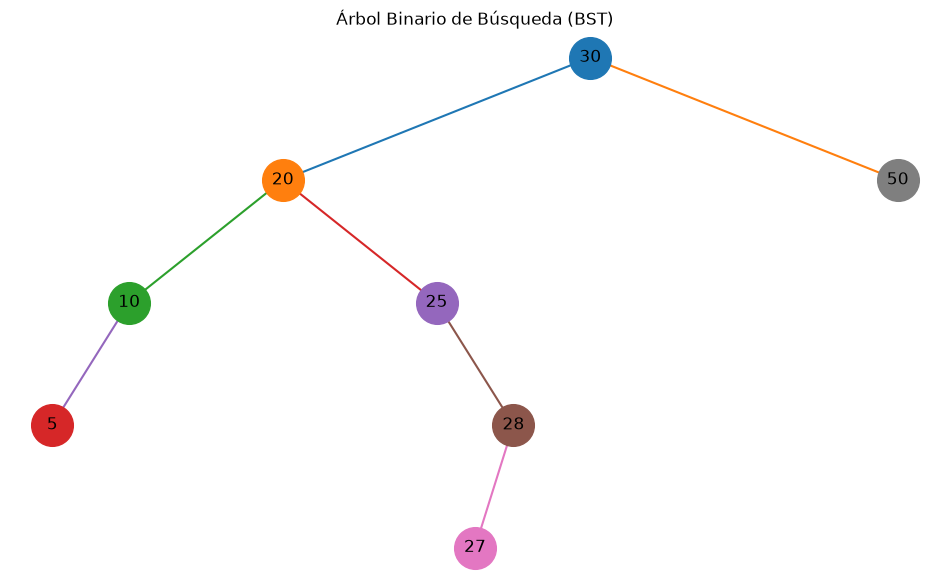

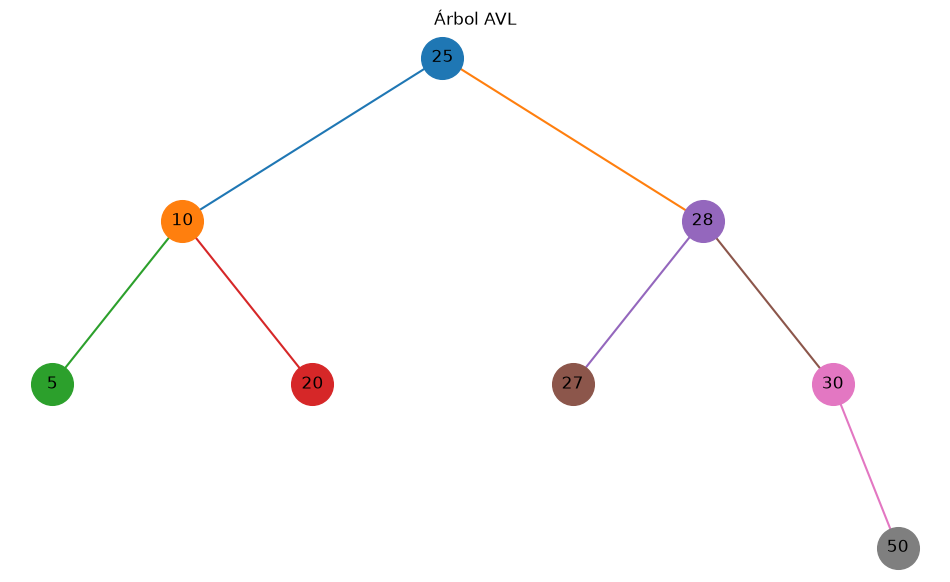

In [26]:


def obtener_posiciones(nodo, x=0, y=0, posiciones=None, nivel=1):
    if posiciones is None:
        posiciones = {}

    if nodo is None:
        return posiciones

    separacion = 1 / (2 ** nivel)

    posiciones[nodo] = (x, y)

    obtener_posiciones(
        nodo.izquierda,
        x - separacion,
        y - 1,
        posiciones,
        nivel + 1
    )

    obtener_posiciones(
        nodo.derecha,
        x + separacion,
        y - 1,
        posiciones,
        nivel + 1
    )

    return posiciones


def dibujar_arbol(raiz, titulo):
    if raiz is None:
        print("El árbol está vacío.")
        return

    posiciones = obtener_posiciones(raiz)

    plt.figure(figsize=(12, 7))

    # Dibujar conexiones primero
    for nodo, (x, y) in posiciones.items():

        if nodo.izquierda is not None:
            x2, y2 = posiciones[nodo.izquierda]
            plt.plot([x, x2], [y, y2], linewidth=1.5)

        if nodo.derecha is not None:
            x2, y2 = posiciones[nodo.derecha]
            plt.plot([x, x2], [y, y2], linewidth=1.5)

    # Dibujar nodos
    for nodo, (x, y) in posiciones.items():
        plt.scatter(x, y, s=900, zorder=2)
        plt.text(
            x, y, str(nodo.valor),
            ha="center",
            va="center",
            fontsize=12,
            zorder=3
        )

    plt.title(titulo)
    plt.axis("off")
    plt.show()


dibujar_arbol(bst.raiz, "Árbol Binario de Búsqueda (BST)")
dibujar_arbol(avl.raiz, "Árbol AVL")


## 7) Recorrido Preorden

Orden:

**Raíz → Izquierda → Derecha**


In [27]:
print("PREORDEN")
print("BST:", preorden(bst.raiz))
print("AVL:", preorden(avl.raiz))


PREORDEN
BST: [30, 20, 10, 5, 25, 28, 27, 50]
AVL: [25, 10, 5, 20, 28, 27, 30, 50]


## 8) Recorrido Inorden

Orden:

**Izquierda → Raíz → Derecha**

Una característica importante del recorrido inorden de un BST es que produce los valores en **orden ascendente**, siempre que no existan valores repetidos.


In [28]:
print("INORDEN")
print("BST:", inorden(bst.raiz))
print("AVL:", inorden(avl.raiz))


INORDEN
BST: [5, 10, 20, 25, 27, 28, 30, 50]
AVL: [5, 10, 20, 25, 27, 28, 30, 50]


## 9) Recorrido Postorden

Orden:

**Izquierda → Derecha → Raíz**


In [29]:
print("POSTORDEN")
print("BST:", postorden(bst.raiz))
print("AVL:", postorden(avl.raiz))


POSTORDEN
BST: [5, 10, 27, 28, 25, 20, 50, 30]
AVL: [5, 20, 10, 27, 50, 30, 28, 25]


## 10) Comparación visual del BST y AVL

Con los datos:

[30, 20, 10, 25, 28, 27, 5, 50]

el BST conserva la estructura generada directamente por el orden de inserción. El AVL, en cambio, modifica la estructura mediante rotaciones para mantener una altura balanceada.

Por esto, aunque ambos árboles contienen exactamente los mismos valores y sus recorridos inorden producen los valores ordenados, sus estructuras y recorridos preorden/postorden pueden ser diferentes.


## 11) Tests aplicados **[15 pts]**

Se verifican:
- Los elementos de ambos árboles.
- El recorrido inorden.
- Que los tres recorridos contengan todos los códigos.
- Que el AVL mantenga factores de balance válidos.


In [30]:


def contar_nodos(nodo):
    if nodo is None:
        return 0

    return (
        1
        + contar_nodos(nodo.izquierda)
        + contar_nodos(nodo.derecha)
    )


def verificar_balance_avl(nodo):
    if nodo is None:
        return True

    balance = avl.factor_balance(nodo)

    if balance < -1 or balance > 1:
        return False

    return (
        verificar_balance_avl(nodo.izquierda)
        and verificar_balance_avl(nodo.derecha)
    )



assert contar_nodos(bst.raiz) == len(codigos)
assert contar_nodos(avl.raiz) == len(codigos)


assert inorden(bst.raiz) == sorted(codigos)
assert inorden(avl.raiz) == sorted(codigos)


assert sorted(preorden(bst.raiz)) == sorted(codigos)
assert sorted(postorden(bst.raiz)) == sorted(codigos)

assert sorted(preorden(avl.raiz)) == sorted(codigos)
assert sorted(postorden(avl.raiz)) == sorted(codigos)


assert verificar_balance_avl(avl.raiz)

print("Todos los tests fueron aprobados correctamente.")


Todos los tests fueron aprobados correctamente.


## 12) Resultados esperados

Para los datos de la actividad:

[30, 20, 10, 25, 28, 27, 5, 50]

el BST queda con una estructura diferente al AVL porque el AVL realiza rotaciones durante las inserciones.

Los recorridos se generan automáticamente al ejecutar las celdas anteriores. El resultado exacto puede comprobarse directamente en el notebook.
